In [1]:
import pandas as pd

from src.evaluate import AllMetrics
from src.visualise import plot_all

# Baseline model evaluation

In [2]:
from src.models import MovingAverageModel

ACTUAL_COL = 'points_next_three'
PREDICTED_COL = 'prediction_next_three'

# Load and predict
df = pd.read_csv('data/merged_data.csv')
model = MovingAverageModel(window=3)
df = model.predict(df)

print(f'Rows: {len(df)}, Seasons: {sorted(df["season"].unique())}')
df[['name', 'season', 'GW', ACTUAL_COL, PREDICTED_COL]].head(5)

/var/folders/wx/6l7zgh9x4cd0fjqhbd7hzs_00000gn/T/ipykernel_90649/1226459922.py:7: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/merged_data.csv')


Rows: 133115, Seasons: ['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']


,name,season,GW,points_next_three,prediction_next_three
76858,Aaron_Anselmino,2024-25,25,0.0,NaN
76859,Aaron_Anselmino,2024-25,26,0.0,0.0
76860,Aaron_Anselmino,2024-25,27,0.0,0.0
76861,Aaron_Anselmino,2024-25,28,0.0,0.0
76862,Aaron_Anselmino,2024-25,29,0.0,0.0


Now compute metrics and plot them.

 season  mean_absolute_error  rank_correlation
2021-22                3.165             0.681
2022-23                2.892             0.713
2023-24                2.644             0.712
2024-25                2.741             0.721
2025-26                2.756             0.747


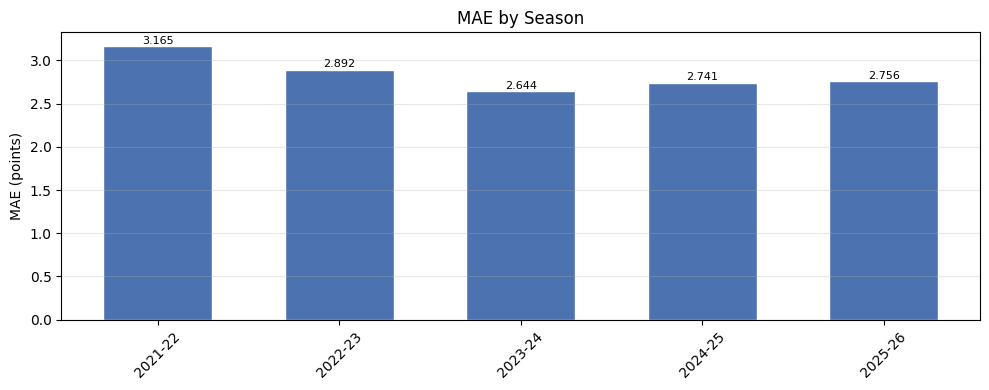

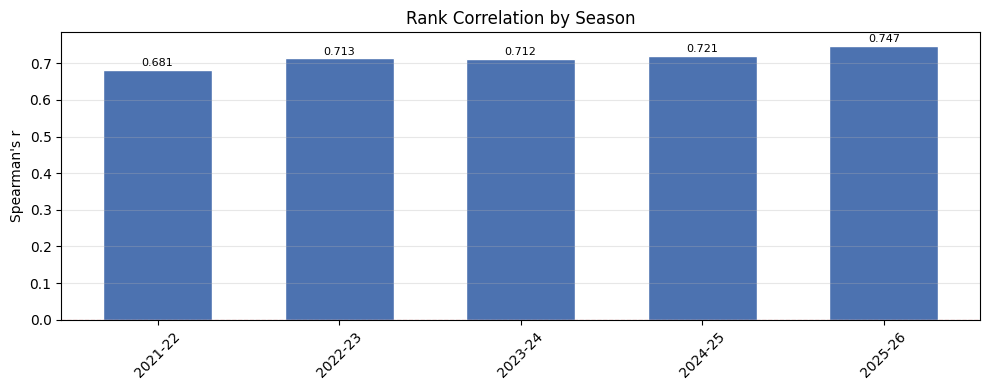

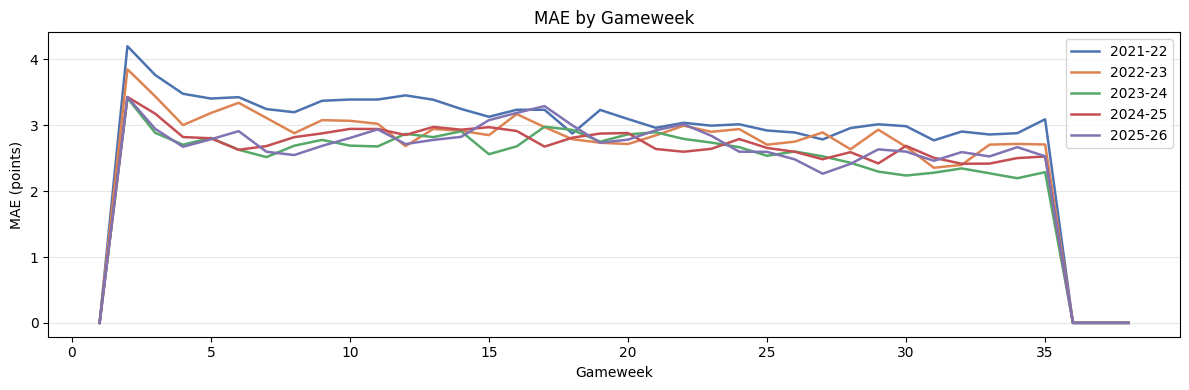

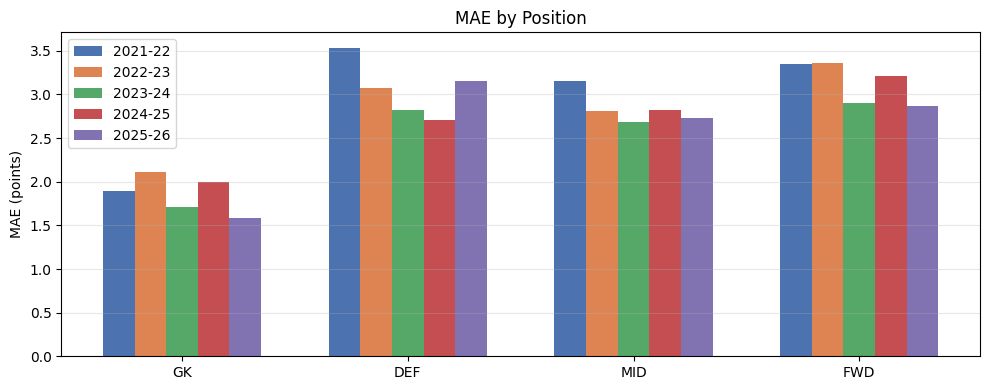

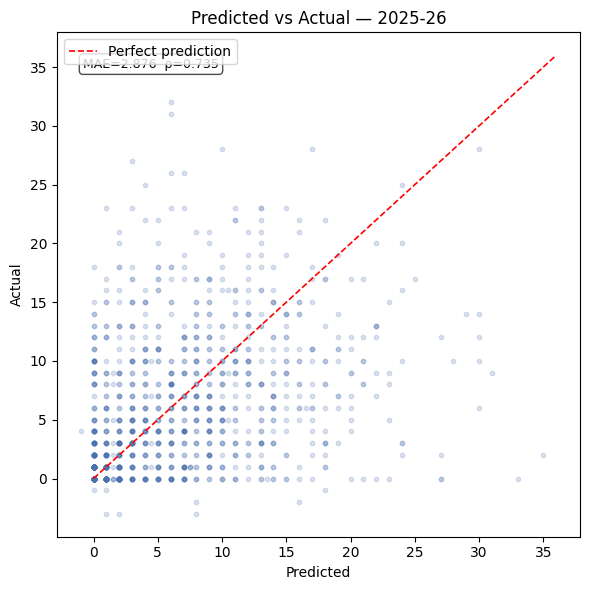

In [3]:
all_metrics = AllMetrics.from_dataframe(df, actual_col=ACTUAL_COL, predicted_col=PREDICTED_COL)

print(all_metrics.summary().to_string(index=False))

plot_all(all_metrics, df, actual_col=ACTUAL_COL, predicted_col=PREDICTED_COL)

# Ridge Regression model

In [4]:
from src.train_model import load_feature_names, seasonal_split, ridge_model, tune_ridge_alpha, train_and_predict
from src.constants import DATA_DIR

# Load data with features
data_path = DATA_DIR / "data_with_features.csv"
feature_config_path = DATA_DIR / "all_feature_names.json"

print(f"Loading data from {data_path}")
df_ridge = pd.read_csv(data_path)

print(f"Loading feature configuration from {feature_config_path}")
feature_cols = load_feature_names(feature_config_path)
print(f"Using {len(feature_cols)} features: {feature_cols}")

Loading data from data/data_with_features.csv
Loading feature configuration from data/all_feature_names.json
Using 24 features: ['total_points_last_1', 'total_points_last_3', 'total_points_last_5', 'minutes_last_1', 'minutes_last_3', 'minutes_last_5', 'expected_goals_last_1', 'expected_goals_last_3', 'expected_goals_last_5', 'expected_assists_last_1', 'expected_assists_last_3', 'expected_assists_last_5', 'expected_goals_conceded_last_1', 'expected_goals_conceded_last_3', 'expected_goals_conceded_last_5', 'bonus_last_1', 'bonus_last_3', 'bonus_last_5', 'was_home', 'value', 'position_GK', 'position_DEF', 'position_MID', 'position_FWD']


In [5]:
TEST_SEASONS = ["2024-25", "2025-26"]
TRAIN_SEASONS = [s for s in df_ridge["season"].unique() if s not in TEST_SEASONS]
TARGET = "points_next_three"

best_alpha = tune_ridge_alpha(
    df=df_ridge,
    target_col=TARGET,
    feature_cols=feature_cols,
    train_seasons=TRAIN_SEASONS,
    cv_splits=2,
)

df_ridge, ridge_metrics = train_and_predict(
    df=df_ridge,
    model=ridge_model(alpha=best_alpha),
    target_col=TARGET,
    test_seasons=TEST_SEASONS,
    feature_cols=feature_cols,
    prediction_col="predicted_pts",
    verbose=True,
)

final_model = ridge_model(alpha=best_alpha)
train_df, test_df = seasonal_split(df_ridge, TEST_SEASONS)
train_clean = train_df.dropna(subset=feature_cols + [TARGET])
X_train = train_clean[feature_cols]
y_train = train_clean[TARGET]
final_model.fit(X_train, y_train)


Seasonal cross-validation (2 folds):
  Fold 1: train on 2021-22 to 2021-22, validate on 2022-23
  Fold 2: train on 2021-22 to 2022-23, validate on 2023-24

  Best alpha: 100.0
  Best CV MAE: 2.6306

PERFORMANCE DIAGNOSTICS

Train set (69745 samples):
  MAE:        2.7088
  Spearman R: 0.7078

Test set (51392 samples):
  MAE:        2.6219
  Spearman R: 0.7263

Generalisation gap:
  MAE gap:        -0.0869 (-3.2%)
  Spearman gap:   -0.0185 (-2.6%)

Overfitting check:
  ✓  Reasonable generalization



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['total_points_last_1','total_points_last_3','total_points_last_5',..., 'position_DEF','position_MID','position_FWD']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaled', ...), ('unscaled', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_featu

Now evaluate the ridge model

 season  mean_absolute_error  rank_correlation
2021-22                  NaN               NaN
2022-23                  NaN               NaN
2023-24                  NaN               NaN
2024-25                2.594             0.725
2025-26                2.648             0.727


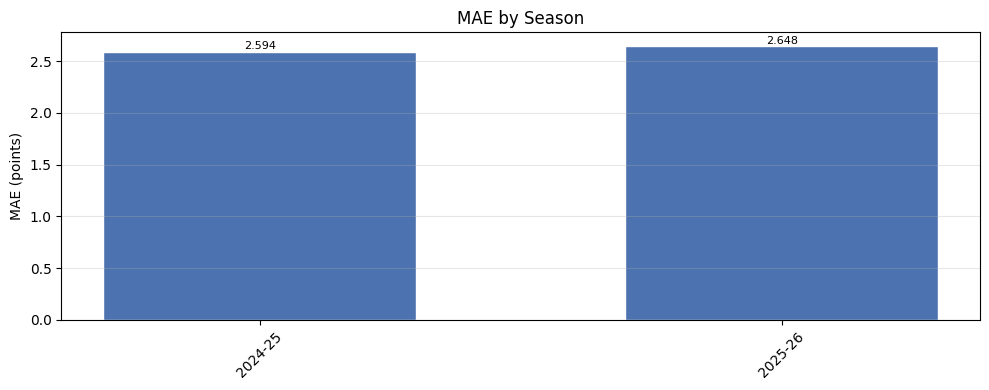

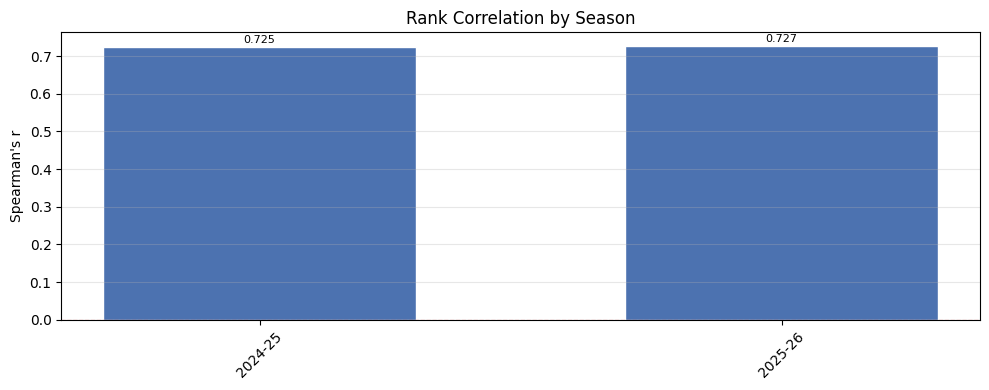

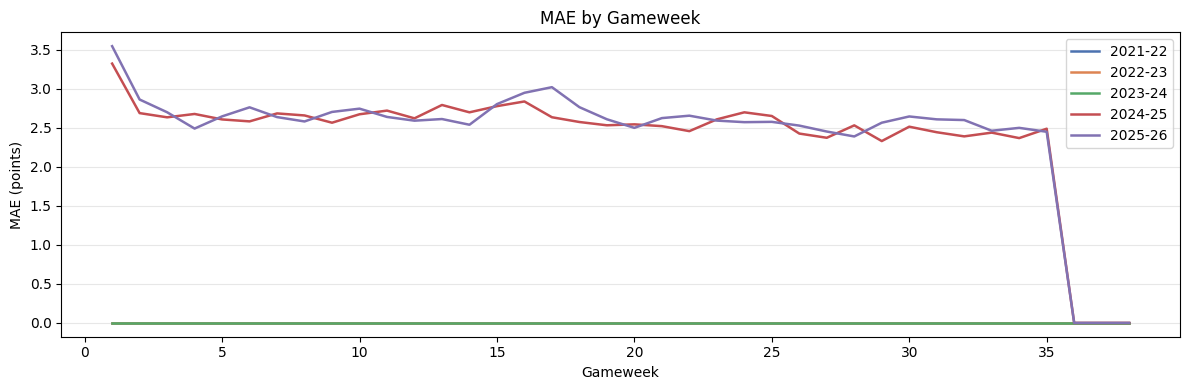

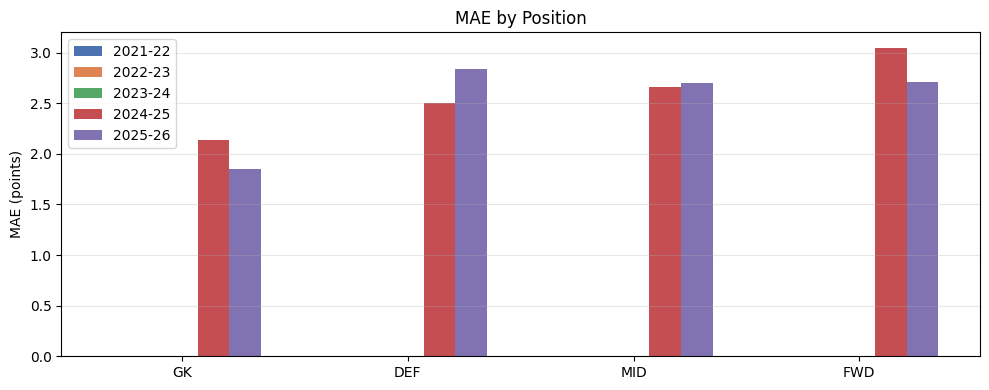

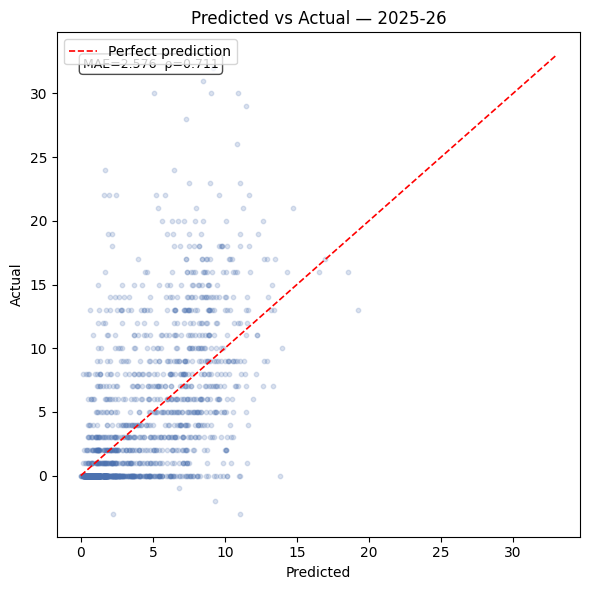

In [6]:
RIDGE_ACTUAL_COL = TARGET
RIDGE_PREDICTED_COL = "predicted_pts"

ridge_all_metrics = AllMetrics.from_dataframe(
    df_ridge, 
    actual_col=RIDGE_ACTUAL_COL, 
    predicted_col=RIDGE_PREDICTED_COL
)

print(ridge_all_metrics.summary().to_string(index=False))
plot_all(ridge_all_metrics, df_ridge, actual_col=RIDGE_ACTUAL_COL, predicted_col=RIDGE_PREDICTED_COL)

## Feature Importance (Ridge Coefficients)

Top 10 most important features (by absolute coefficient):
                feature  coefficient  abs_coefficient
                  value     1.303663         1.303663
         minutes_last_1     1.145434         1.145434
    total_points_last_5     0.912313         0.912313
         minutes_last_5     0.643945         0.643945
           position_FWD    -0.508914         0.508914
            position_GK     0.394676         0.394676
           position_DEF     0.251278         0.251278
           bonus_last_5    -0.233958         0.233958
expected_assists_last_5     0.208281         0.208281
    total_points_last_3     0.171980         0.171980


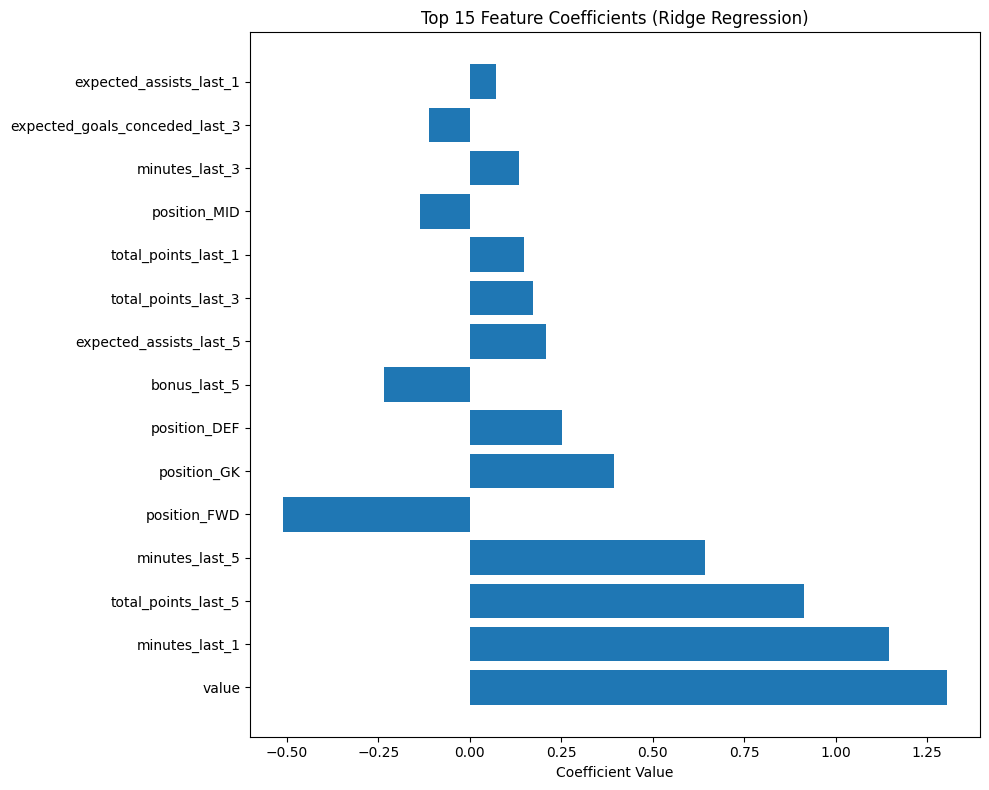

In [7]:
import matplotlib.pyplot as plt

# Extract coefficients from the Ridge model
ridge_regressor = final_model.named_steps['model']
coefficients = ridge_regressor.coef_
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': coefficients,
    'abs_coefficient': abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print("Top 10 most important features (by absolute coefficient):")
print(coef_df.head(10).to_string(index=False))

# Plot coefficients
plt.figure(figsize=(10, 8))
plt.barh(coef_df['feature'].head(15), coef_df['coefficient'].head(15))
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Coefficients (Ridge Regression)')
plt.tight_layout()
plt.show()